Iniciando a exploração dos dados

In [1]:
import pandas as pd

df = pd.read_csv('..//data/train.csv', parse_dates=['date'])

print(df.shape)
print(df.dtypes)
df.head()

(3000888, 6)
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [3]:
print(df['family'].nunique())    # quantas categorias de produto
print(df['store_nbr'].nunique()) # quantas lojas
print(df['date'].min(), df['date'].max()) # período

33
54
2013-01-01 00:00:00 2017-08-15 00:00:00


<Axes: title={'center': 'Vendas totais por dia'}, xlabel='date'>

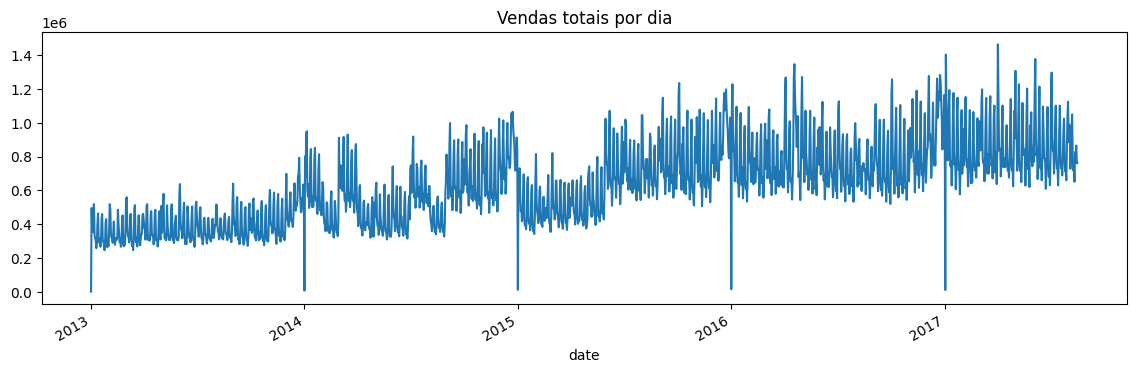

In [5]:
vendas_dia = df.groupby('date')['sales'].sum()
vendas_dia.plot(figsize=(14, 4), title='Vendas totais por dia')

<Axes: title={'center': 'Média de vendas por dia da semana'}, xlabel='weekday'>

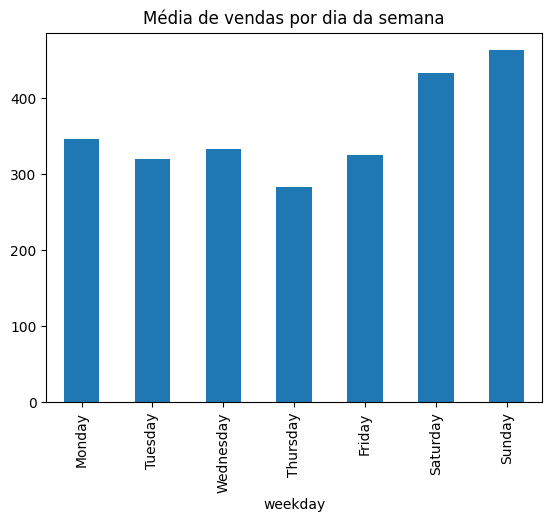

In [8]:
df['weekday'] = df['date'].dt.day_name()
df.groupby('weekday')['sales'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).plot(kind='bar', title='Média de vendas por dia da semana')